# AR modeling

In [47]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

from utils import data_loader_utils
from utils import user_defined_functions as udf


# Same as it shows in Decision_Tree.ipynb
DATA_ROOT = Path("./data")
OP = "OP07"
TRAIN_MACHINE = "M01"
TEST_MACHINES = ["M02", "M03"]

ORIGINAL_FS = 2000
TARGET_FS = 1000
WS = 4096   # the paper also indicates the same window length

P = 20  # AR order
TAU_Q = 0.99    # the threshold of M01 when its ok

In [26]:
def list_h5_files(machine, op, label):
    # label: "good" / "bad"
    folder = DATA_ROOT / machine / op / label
    return sorted(folder.glob("*.h5"))

def load_xyz(file_path):
    arr = data_loader_utils.datafile_read(file_path, False)
    return arr[:, :3]

# downsample to 1khz
def resample_xyz(xyz, fs_in=ORIGINAL_FS, fs_out=TARGET_FS):
    xs = udf.resample_milling_data(xyz[:,0], fs_in, fs_out)
    ys = udf.resample_milling_data(xyz[:,1], fs_in, fs_out)
    zs = udf.resample_milling_data(xyz[:,2], fs_in, fs_out)
    return np.stack([xs, ys, zs], axis=1)

# normalize every window (z-score)
def zscore_per_window(w, eps=1e-8):
    mu = w.mean(axis=0, keepdims=True)
    sd = w.std(axis=0, keepdims=True) + eps
    return (w - mu) / sd

def sliding_windows(xyz: np.ndarray, ws=WS):
    n = len(xyz)
    out = []
    for start in range(0, n - ws + 1, int(float(ws)/2)):
        out.append(xyz[start:start+ws])
    return out

In [22]:
train_ok_files = list_h5_files(TRAIN_MACHINE, OP, "good")
test_files = []
for m in TEST_MACHINES:
    test_files += [(m, "good", f) for f in list_h5_files(m, OP, "good")]
    test_files += [(m, "bad",  f) for f in list_h5_files(m, OP, "bad")]

print("Train OK files:", len(train_ok_files))
print("Test files:", len(test_files))

Train OK files: 43
Test files: 111


## Build Data
Only use good data for training, but test has both good and bad data

In [33]:
def build_windows_from_files(file_list, label_int=None):
    # label_int: if it's None then it's for training, otherwise for testing
    windows = []
    labels = []
    groups = []
    for fp in file_list:
        xyz = load_xyz(fp)
        xyz = resample_xyz(xyz)
        ws_list = sliding_windows(xyz, WS)
        for w in ws_list:
            w = zscore_per_window(w)
            windows.append(w)
            if label_int is not None:
                labels.append(label_int)
            groups.append(fp.name)
    if label_int is None:
        return windows, groups
    return windows, np.array(labels, dtype=int), groups

# Train windows, label_int = None by default
train_windows, train_groups = build_windows_from_files(train_ok_files)
print("Train windows:", len(train_windows))

# Test windows, for M02 and M03
test_windows = []
test_labels = []
test_groups = []
test_machines = []

for (m, lab, fp) in test_files:
    w_list, y_list, g_list = build_windows_from_files([fp], label_int=(0 if lab=="good" else 1))
    test_windows += w_list
    test_labels += list(y_list)
    test_groups += g_list
    test_machines += [m]*len(w_list)

test_labels = np.array(test_labels, dtype=int)
print("Test windows:", len(test_windows), "Bad data ratio:", test_labels.mean())


Train windows: 473
Test windows: 1180 Bad data ratio: 0.03728813559322034


## Build AR model

In [ ]:
def fit_ar_coeffs(x, p: int):
    """
    Find coefficiency
    x: 1D array
    return: coeffs a shape=(p,)
    """
    x = np.asarray(x).astype(float)
    y = x[p:]
    Phi = np.column_stack([x[p-k-1:-(k+1)] for k in range(p)])  # t-1..t-p
    # y = Phi @ a
    a, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    return a

def concat_axis(train_windows, axis_idx: int):
    return np.concatenate([w[:, axis_idx] for w in train_windows], axis=0)

# For 3 axis
a_x = fit_ar_coeffs(concat_axis(train_windows, 0), P)
a_y = fit_ar_coeffs(concat_axis(train_windows, 1), P)
a_z = fit_ar_coeffs(concat_axis(train_windows, 2), P)
# Shape: (P,)

tau = 1.0090873125952806


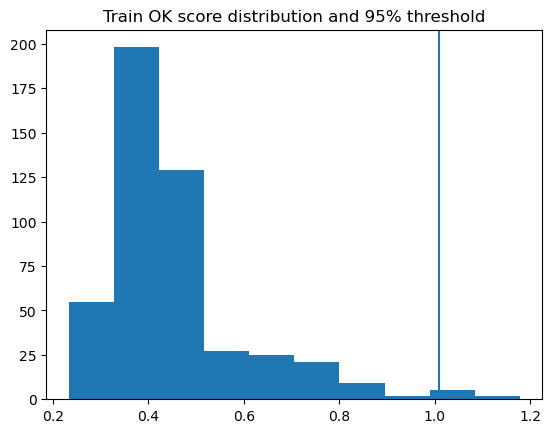

In [48]:
def ar_residual_mse(x, a):
    """
    x: 1D window
    a: AR coefficient (p,)
    return: mean squared residual
    """
    p = len(a)
    x = np.asarray(x).astype(float)
    if len(x) <= p: # if length of window not enough for prediction return Nan
        return np.nan
    # xhat[t] = sum_{k=1..p} a[k-1] * x[t-k]
    y = x[p:]
    Phi = np.column_stack([x[p-k-1:-(k+1)] for k in range(p)])
    yhat = Phi @ a
    r = y - yhat
    return float(np.mean(r**2))

def window_score(w):
    sx = ar_residual_mse(w[:,0], a_x)
    sy = ar_residual_mse(w[:,1], a_y)
    sz = ar_residual_mse(w[:,2], a_z)
    return sx + sy + sz

train_scores = np.array([window_score(w) for w in train_windows], dtype=float)
train_scores = train_scores[np.isfinite(train_scores)]  # exclude all the Nans

tau = np.quantile(train_scores, TAU_Q)
print("tau =", tau) # 95%

plt.figure()
plt.hist(train_scores)
plt.axvline(tau)
plt.title("Train OK score distribution and 95% threshold")
plt.show()


In [49]:
test_scores = np.array([window_score(w) for w in test_windows], dtype=float)
pred = (test_scores > tau).astype(int)  # 1=NOK, 0=OK

print("Accuracy:", accuracy_score(test_labels, pred))
print("F1:", f1_score(test_labels, pred))
print(confusion_matrix(test_labels, pred))


Accuracy: 0.9194915254237288
F1: 0.4808743169398907
[[1041   95]
 [   0   44]]


The confusion matrix above shows a very good result, it shows no missing detections (NOK recall=1).